### **LangGraph**

#### ***Assignment-2***
1. you have to create one supervisor node.
2. create one router function
3. create three more node
    - 3.1 llm call (llm node)
    - 3.2 RAG (rag node)
    - 3.3 web crawler(fetch the info in realtime from internet)
4. created one more node after this for validation for generated output --> explore the validation part how to do that
5. if validation going to be failed in that case again go to supervioser node and then supervisor node will again decide what needs to be call next
6. once the validation will pass then only generate the final output

submission deadline till 9pm friday

submission instruction:
create your github repo and keep all the assisgnments over there(in that github repo)
i will share one googleform in group after completing your assignment you can share the github link through that google form. 

##### Initialized Python's library

In [1]:
import operator
from typing import TypedDict, Sequence, Annotated 
from langchain_core.messages import BaseMessage 
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter 
from langchain_community.vectorstores import Chroma, FAISS
from langchain_core.prompts import PromptTemplate 
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser, StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_community.tools import TavilySearchResults, DuckDuckGoSearchRun

##### Config Model

In [2]:
model= ChatGoogleGenerativeAI(model="gemini-1.5-flash")
response= model.invoke("Hi")
print(response.content)

Hi there! How can I help you today?


##### Loading text files into documents

In [3]:
# FILE_PATH=r"C:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\data2\usa.txt"
# loader= TextLoader(file_path=FILE_PATH)
loader= DirectoryLoader("../data2", glob="./*.txt", loader_cls=TextLoader)
docs= loader.load()
print(docs )
print(len(docs))

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content="🇺🇸 Overview of the U.S. Economy\nThe United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services. It has a highly diversified structure with strong sectors in technology, healthcare, finance, real estate, defense, and agriculture.\n\nU.S. GDP – Size, Composition, and Global Share\nAs of 2024, the United States’ nominal GDP is estimated to be around $28 trillion USD, accounting for approximately 25% of the global economy. It ranks #1 in the world by nominal GDP, far ahead of China (which ra

##### Now We are performing Chunking

In [4]:
text_splitter= RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=50)
final_docs= text_splitter.split_documents(documents=docs)
print(final_docs)
print(len(final_docs))

[Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='🇺🇸 Overview of the U.S. Economy'), Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='The United States of America possesses the largest economy in the world in terms of nominal GDP, making it the most powerful economic force globally. It operates under a capitalist mixed economy,'), Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='It operates under a capitalist mixed economy, where the private sector dominates, but the government plays a significant regulatory and fiscal role. With a population of over 335 million people and a'), Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='a population of over 335 million people and a high level of technological advancement, the U.S. economy thrives on a foundation of consumer spending, innovation, global trade, and financial services.'), Document(metadata={'source': '..\\data2\\usa.txt'}, page_content='innovation, global trade, and

##### Hugging Face Embeddings Models

In [5]:
embeddings= HuggingFaceEmbeddings(model_name="BAAI/bge-small-en")
embeddings

c:\Users\Satish\OneDrive\AgenticAI\AgenticAI2.0\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HuggingFaceEmbeddings(model_name='BAAI/bge-small-en', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

##### Checking Dimension(Feature Represenatation) of Hugging Face Embeddings models

In [6]:
len(embeddings.embed_query("Hi"))

384

In [7]:
db= Chroma.from_documents(documents=final_docs, embedding=embeddings)
retriever= db.as_retriever(search_kwargs={"k": 3})
retriever

VectorStoreRetriever(tags=['Chroma', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x000002176832CD70>, search_kwargs={'k': 3})

In [8]:
class TopicSelectionParser(BaseModel):
    Topic:str = Field(description="selected topic")
    Reasoning:str = Field(description="Reasoning behind topic selection")

In [9]:
parser= PydanticOutputParser(pydantic_object=TopicSelectionParser)

In [10]:
parser.get_format_instructions()

'The output should be formatted as a JSON instance that conforms to the JSON schema below.\n\nAs an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}\nthe object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.\n\nHere is the output schema:\n```\n{"properties": {"Topic": {"description": "selected topic", "title": "Topic", "type": "string"}, "Reasoning": {"description": "Reasoning behind topic selection", "title": "Reasoning", "type": "string"}}, "required": ["Topic", "Reasoning"]}\n```'

In [11]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [144]:
# Supervisor Function
def supervisor_node(state:AgentState):
    question= state["messages"][-1]
    print("Question", question)

    template= """
    You are an intelligent classifier.

    Given a user query, identify which of the following categories it belongs to:
    1. Internet Search - if the user is likely asking for recent, real-time, or external web-based information (e.g., news, weather, current events, trending topics, live data).
    2. LLM Call - if the user query can be answered using general knowledge, reasoning, or common sense, and does not require external data or proprietary documents.
    3. RAG Call - If the user is asking about any realted to USA.

    Return only one of: `Internet Search`, `LLM Call`, or `RAG Call`
        
    User query: {question}
    {format_instructions}
    """
    prompt= PromptTemplate(
        template= template,
        input_variables= ["question"],
        partial_variables= {"format_instructions": parser.get_format_instructions()}
    )

    chain= prompt | model | parser
    response= chain.invoke({"question": question})
    print("Parsed response:", response)

    return {"messages": [response.Topic]}

In [ ]:
# Router Function
def router_function(state:AgentState):
    print("-> ROUTER ->")
    
    last_message= state["messages"][-1]
    print("last_message:", last_message)

    if "rag call" in last_message.lower():
        return "RAG Call"
    elif "llm call" in last_message.lower():
        return "LLM Call"
    elif "internet search" in last_message.lower():
        return "WEB Call"

In [19]:
def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [20]:
# RAG Function
def rag_node(state:AgentState):
    print("-> RAG Call ->")
    question= state["messages"][0]
    
    prompt= PromptTemplate(
        template=""" 
        You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. 
        If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\n
        Question: {question} \nContext: {context} \nAnswer:
        """,
        input_variables=["context", "question"]
    )

    rag_chain= (
        {"context": retriever | format_docs, "question": RunnablePassthrough()}
        | prompt
        | model
        | StrOutputParser()
        )

    result= rag_chain.invoke(question)
    return {"messages": [result]}

In [21]:
# LLM Function
def llm_node(state:AgentState):
    print("-> LLM Call ->")

    question= state["messages"][0]

    # Normal LLM Call
    complete_query= "Answer the follow question with you knowledge of the real world. Following is the user question: " + question
    response= model.invoke(complete_query)
    return {"messages": [response.content]}

In [22]:
def web_crawler_node(state:AgentState):
    print("-> Web Call ->") 

    question= state["messages"][0]
    print(question)

    tool= TavilySearchResults()
    response= tool.invoke(question)
    return {"messages": [response]}

In [153]:
def validation_node(state:AgentState):
    print("-> Validation ->")
    question= state["messages"][0]
    answer= state["messages"][-1]

    print("Answer:", answer)
    template=""" 
    Your task is to check if the response is related to the user question. 
    Only respond with yes or no and nothing else.

    User query: {question}
    response: {answer}
    {format_instructions}
    """
    prompt= PromptTemplate(
        template=template,
        input_variables=["question", "answer"],
        partial_variables={"format_instructions": parser.get_format_instructions()}
    )

    chain= prompt | model | parser
    response= chain.invoke({"question": question, "answer": answer})
    print("parserd response:", response)

    return {"messages": [response.Topic]}

In [154]:
# Validation Router
def router_valid_function(state: AgentState):
    print("-> ROUTER VALIDATION ->")
    last_message= state["messages"][-1]
    print("last_message:", last_message)

    if "yes" in last_message.lower():
        return "Yes"
    else:
        return "No"

In [155]:
# Create the workflow
workflow= StateGraph(AgentState)

# Add nodes to the workflow
workflow.add_node("Supervisor", supervisor_node)
workflow.add_node("RAG", rag_node)
workflow.add_node("LLM", llm_node)
workflow.add_node("Web Crawler", web_crawler_node)
workflow.add_node("Validation", validation_node)

# Set the entry point
workflow.set_entry_point("Supervisor")

In [156]:
# Add conditional edge
workflow.add_conditional_edges(
    "Supervisor",
    router_function,
    {
        "RAG Call": "RAG",
        "LLM Call": "LLM",
        "WEB Call": "Web Crawler",
    },
)

workflow.add_conditional_edges(
    "Validation",
    router_valid_function,
    {
        "No": "Supervisor",
        "Yes": END
    }
)

In [157]:
# Add edges between nodes

workflow.add_edge("RAG", "Validation")
workflow.add_edge("LLM", "Validation")
workflow.add_edge("Web Crawler", "Validation")

In [158]:
app= workflow.compile()

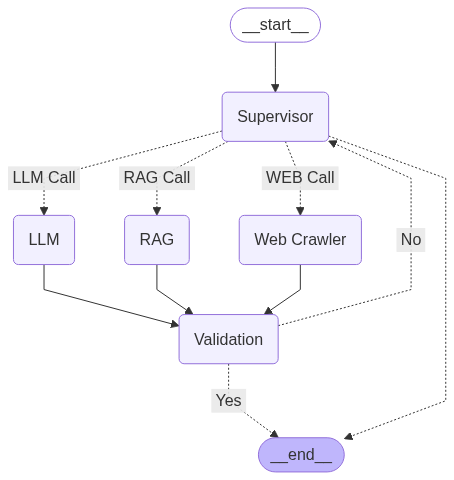

In [130]:
from IPython.display import display, Image

display(Image(app.get_graph(xray=True).draw_mermaid_png()))

#### Scenario to invoke RAG Call

In [159]:
state={"messages": ["what is gdp of usa"]}
state

{'messages': ['what is gdp of usa']}

In [160]:
response= app.invoke(state)
response

Question what is gdp of usa
Parsed response: Topic='RAG Call' Reasoning='The query explicitly asks for information related to the USA (GDP of USA), requiring access to a knowledge base or external data source about the USA.'
-> ROUTER ->
last_message: RAG Call
-> RAG Call ->
-> Validation ->
Answer: As of 2024, the nominal GDP of the USA is estimated to be around $28 trillion USD.  This represents approximately 25% of the global economy.  It holds the #1 ranking worldwide by nominal GDP.
parserd response: Topic='yes' Reasoning="The response directly answers the user's question about the GDP of the USA by providing a numerical estimate and context."
-> ROUTER VALIDATION ->
last_message: yes


{'messages': ['what is gdp of usa',
  'RAG Call',
  'As of 2024, the nominal GDP of the USA is estimated to be around $28 trillion USD.  This represents approximately 25% of the global economy.  It holds the #1 ranking worldwide by nominal GDP.',
  'yes']}

#### Scenario to invoke LLM Call

In [161]:
state={"messages": ["what is agentic AI"]}
state

{'messages': ['what is agentic AI']}

In [162]:
response= app.invoke(state)
response

Question what is agentic AI
Parsed response: Topic='LLM Call' Reasoning="The query 'what is agentic AI' can be answered using general knowledge and reasoning about artificial intelligence.  It does not require accessing external websites or specific documents related to the USA."
-> ROUTER ->
last_message: LLM Call
-> LLM Call ->
-> Validation ->
Answer: Agentic AI refers to artificial intelligence systems that are capable of independent action in the world.  Unlike reactive AI, which simply responds to inputs, or deliberative AI, which plans actions based on pre-programmed rules, agentic AI has the ability to:

* **Set its own goals:**  An agentic AI doesn't just follow instructions; it can formulate its own objectives, even if those objectives are within a pre-defined scope.
* **Plan and execute actions:** It can develop strategies to achieve its goals, taking into account the environment and potential obstacles.
* **Learn and adapt:** Agentic AI systems can improve their performance

{'messages': ['what is agentic AI',
  'LLM Call',
  'Agentic AI refers to artificial intelligence systems that are capable of independent action in the world.  Unlike reactive AI, which simply responds to inputs, or deliberative AI, which plans actions based on pre-programmed rules, agentic AI has the ability to:\n\n* **Set its own goals:**  An agentic AI doesn\'t just follow instructions; it can formulate its own objectives, even if those objectives are within a pre-defined scope.\n* **Plan and execute actions:** It can develop strategies to achieve its goals, taking into account the environment and potential obstacles.\n* **Learn and adapt:** Agentic AI systems can improve their performance over time through experience and feedback.  This might involve learning new strategies, refining existing ones, or adapting to changes in the environment.\n* **Interact with the environment:** It can actively interact with and influence its surroundings, not just passively observe them. This could

#### Scenario to invoke Tavily Search

In [163]:
state={"messages": ["The latest new about 'the Bengal File'"]}
state

{'messages': ["The latest new about 'the Bengal File'"]}

In [164]:
response= app.invoke(state)
response

Question The latest new about 'the Bengal File'
Parsed response: Topic='Internet Search' Reasoning="The query explicitly asks for the latest news about a specific topic ('The Bengal File').  This requires accessing and processing up-to-date information from external sources, which is characteristic of an internet search."
-> ROUTER ->
last_message: Internet Search
-> Web Call ->
The latest new about 'the Bengal File'
-> Validation ->
Answer: [{'title': "The Bengal Files teaser: Vivek Agnihotri's final film in the Files trilogy ...", 'url': 'https://indianexpress.com/article/entertainment/bollywood/the-bengal-files-teaser-vivek-agnihotris-final-film-in-the-files-trilogy-has-anupam-kher-playing-gandhi-and-mithun-chakraborty-as-a-madman-watch-10062398/', 'content': '###### [Jun 17: Latest News](/latest-news/) [...] Originally titled The [Delhi](https://indianexpress.com/section/cities/delhi/) Files: Bengal Chapter, the film was recently renamed The Bengal Files, and is set to explore the 

{'messages': ["The latest new about 'the Bengal File'",
  'Internet Search',
  [{'title': "The Bengal Files teaser: Vivek Agnihotri's final film in the Files trilogy ...",
    'url': 'https://indianexpress.com/article/entertainment/bollywood/the-bengal-files-teaser-vivek-agnihotris-final-film-in-the-files-trilogy-has-anupam-kher-playing-gandhi-and-mithun-chakraborty-as-a-madman-watch-10062398/',
    'content': '###### [Jun 17: Latest News](/latest-news/) [...] Originally titled The [Delhi](https://indianexpress.com/section/cities/delhi/) Files: Bengal Chapter, the film was recently renamed The Bengal Files, and is set to explore the fundamental question: What is India? An earlier teaser featured Mithun Chakraborty solemnly reading the Preamble to the Indian Constitution. Agnihotri’s past films have sparked intense debate and polarized public opinion, yet achieved commercial success. With The Bengal Files slated for release on September 5,',
    'score': 0.69870013},
   {'title': 'The B

#### Tested Invalid Scenario

In [166]:
state={"messages": ["Wiki"]}
state

{'messages': ['Wiki']}

In [167]:
response= app.invoke(state)
response

Question Wiki
Parsed response: Topic='LLM Call' Reasoning='The query "Wiki" is too broad.  It doesn\'t request specific information requiring an internet search or necessitate access to a specific knowledge base related to the USA.  An LLM can provide information about Wikipedia itself, its history, purpose, and function.'
-> ROUTER ->
last_message: LLM Call
-> LLM Call ->
-> Validation ->
Answer: Please provide the user's question about Wiki.  I need the question to be able to answer it.
parserd response: Topic='no' Reasoning='The response is a request for clarification, not an answer about Wiki.'
-> ROUTER VALIDATION ->
last_message: no
Question no
Parsed response: Topic='LLM Call' Reasoning="The query 'no' is not a question and does not require any external information or reasoning about specific real-world data.  It's too vague to classify as an internet search or a RAG call."
-> ROUTER ->
last_message: LLM Call
-> LLM Call ->
-> Validation ->
Answer: The word "Wiki" by itself does

Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_dimensions {
    key: "model"
    value: "gemini-1.5-flash"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 32
}
].


ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. [violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_dimensions {
    key: "model"
    value: "gemini-1.5-flash"
  }
  quota_value: 15
}
, links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, retry_delay {
  seconds: 30
}
]